In [23]:
import stim

from spidercat.utils import qasm_to_stim
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp
from spiderstate.stim_utils import get_circuit_depth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import random

code = "17_1_5"
state = "0"
max_col_ops = 100

random.seed(1)

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="X", top_n=50, num_circuits=1, state=state
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Num Meas: {count_operations(final_circ)[1]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

Loading QECC: 17_1_5
Optimizing parity matrix (max_col_ops=100, num_circuits=1)...
Finding unique matrix configuration
Cost of final M: 12
Chosen 11 CNOT gates: [(9, 13), (1, 13), (16, 2), (10, 12), (10, 16), (10, 3), (2, 0), (3, 2), (10, 15), (10, 4), (13, 10)]
Computing initial single faults...

Running verification stabilizers search for t=2 layers (top_n=50, first_layer=X)...

--- X Faults Verification (Non-FT) ---
Found 255 stabilizers


Generating mixed faults: 100%|██████████| 45/45 [00:00<00:00, 4919.56it/s]


Found 159 active errors
  [Layer 1] Expanding beam of size 1:



  8%|▊         | 4/50 [00:00<00:00, 83468.74it/s]


  -> Kept top 5 states. Best Lookahead Score: 20.06
  [Layer 2] Expanding beam of size 5:


...

Found 91 active errors
  [Layer 1] Expanding beam of size 1:



  8%|▊         | 4/50 [00:00<00:00, 83055.52it/s]


  -> Kept top 5 states. Best Lookahead Score: 34.0
  [Layer 2] Expanding beam of size 5:


 80%|████████  | 4/5 [00:00<00:00, 76959.71it/s]


  -> Kept top 5 states. Best Lookahead Score: 34.0
Computing T_E_Q...
Finding the best circuits in the beam...
  [Chosen Stabilizers] (Violations: 0)
    -> Layer 1: ['00000100001011000', '00001011001110011', '10010010000000001']
    -> Layer 2: []

Synthesizing X fault verification circuits...

Synthesizing Z fault verification circuits...

--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 25
Num CX: 63
Num Meas: 11
Total instructions: 74
Depth: 27


Total Qubits: 25
Num CX: 63
Total instructions: 74
Depth: 27


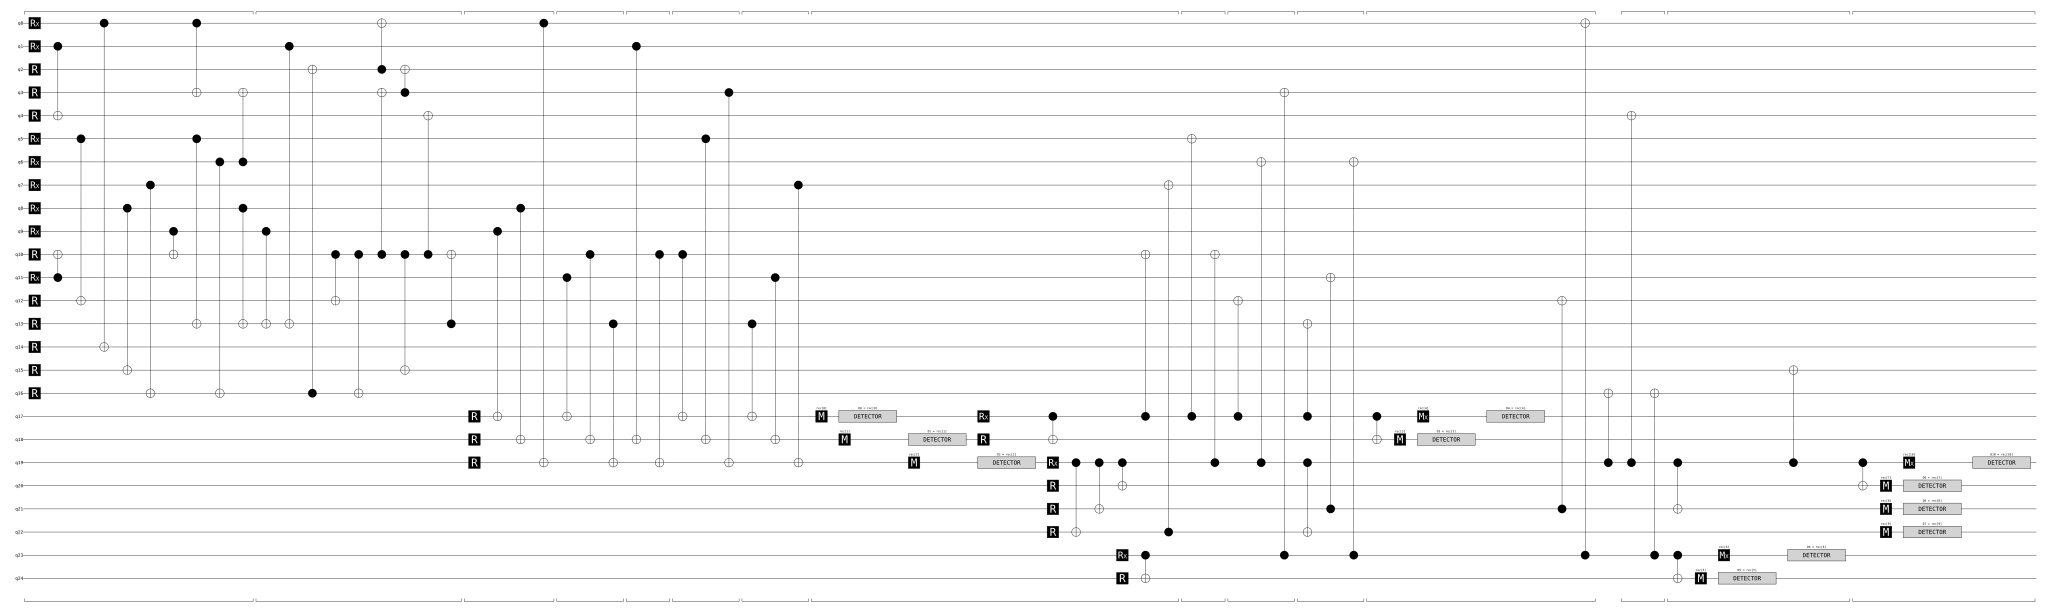

In [34]:
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

final_circ.diagram('timeline-svg')

In [10]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]

if state == "0":
    H_primary=H_z; L_primary=np.atleast_2d(L_z)
    H_conjugate=H_x; L_conjugate=np.atleast_2d(L_x)
    primary_basis="Z"; conjugate_basis="X"
else:
    H_primary=H_x; L_primary=np.atleast_2d(L_x)
    H_conjugate=H_z; L_conjugate=np.atleast_2d(L_z)
    primary_basis="X"; conjugate_basis="Z"
    primary_basis="Z"; conjugate_basis="X"


print(meas_samples @ H_primary.T % 2)
print((meas_samples @ L_primary.T % 2).T)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [11]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_primary , L_primary=L_primary,
        H_conjugate=H_primary, L_conjugate=L_conjugate,
        d=d, t=d // 2,
        primary_basis=primary_basis, conjugate_basis=primary_basis,
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis via Combinatorics (d=4, t=2)...
    [PASS] No uncorrectable conjugate cascades found.

  [Conjugate] Evaluating Z-basis via Combinatorics (t=2)...
    [PASS] No uncorrectable conjugate cascades found.
Verification Result: True


In [12]:
with open("res_exhaustive.svg", "w") as f:
    f.write(str(res_exhaustive.diagram("timeline-svg")))

AttributeError: 'bool' object has no attribute 'diagram'

In [13]:
if False:
    state_str = "" if state == "0" else "_plus"
    file = get_project_root().joinpath("good_circuits", f"{code}{state_str}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

Num CX: 194
Num Meas: 38
Total instructions: 232
Depth: 31


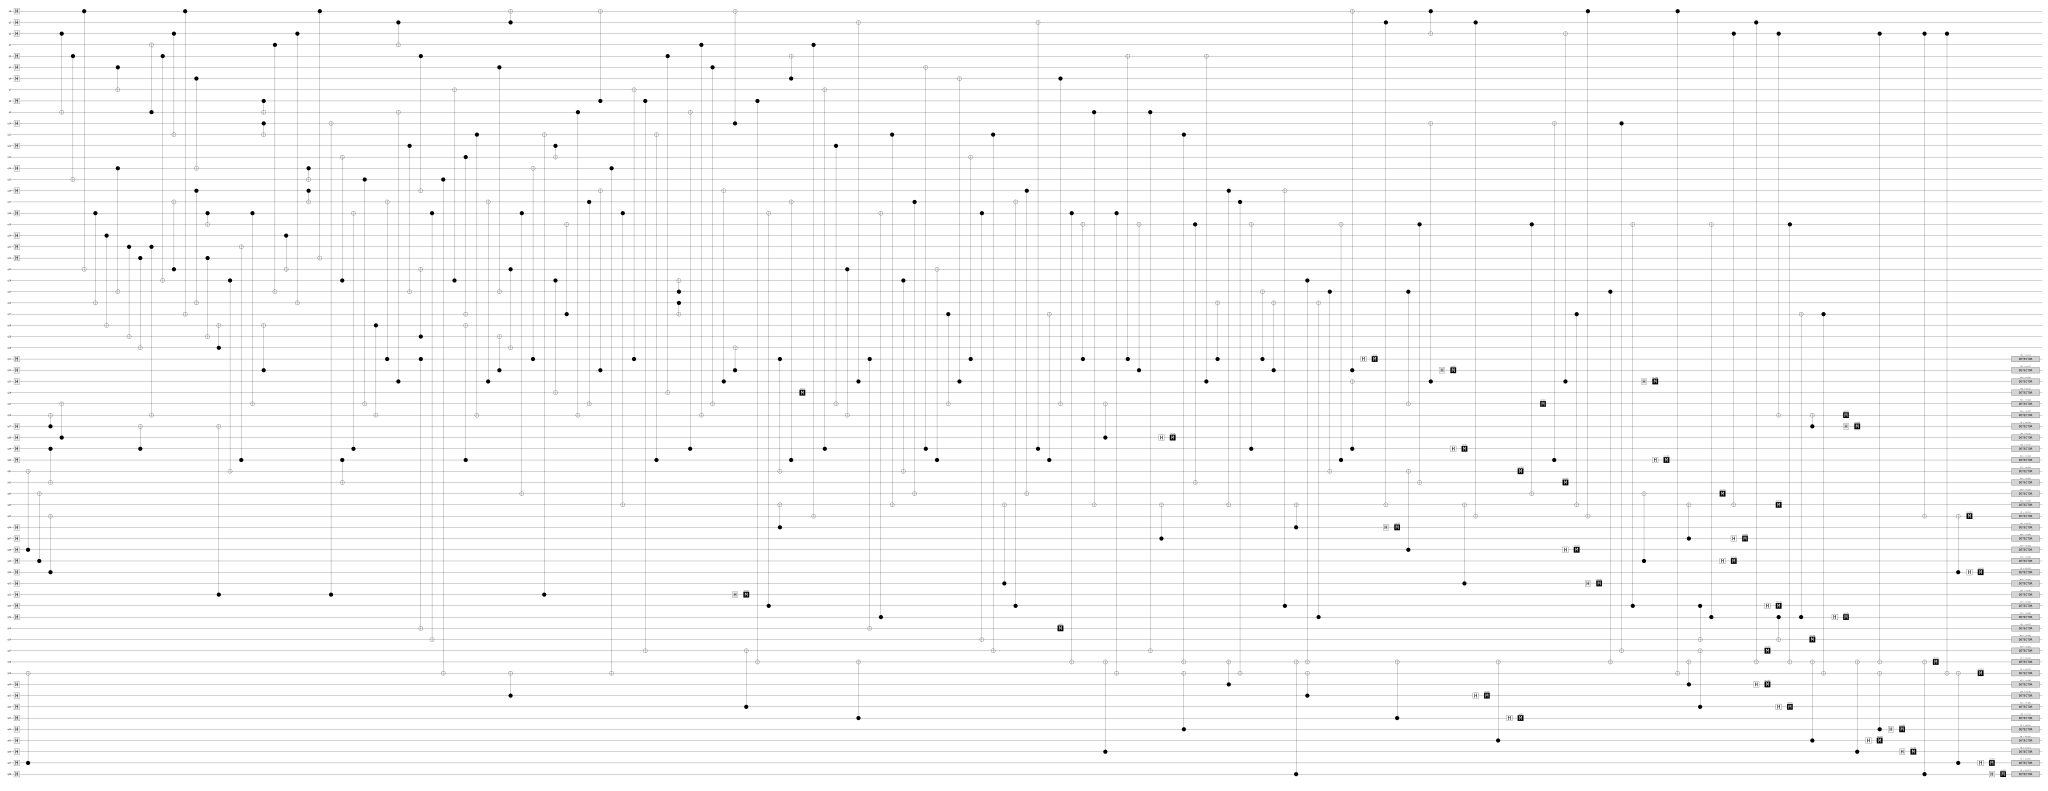

In [14]:
bens_circ = qasm_to_stim("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[69];
creg c[38];
h q[68];
h q[66];
h q[67];
h q[60];
h q[61];
h q[62];
h q[63];
h q[64];
h q[65];
h q[52];
h q[53];
h q[54];
h q[51];
h q[46];
h q[47];
h q[48];
h q[49];
h q[50];
h q[39];
h q[40];
h q[37];
h q[38];
h q[31];
h q[32];
h q[33];
h q[0];
h q[1];
h q[2];
h q[4];
h q[5];
h q[6];
h q[8];
h q[10];
h q[12];
h q[14];
h q[16];
h q[18];
h q[20];
h q[21];
h q[22];
cx q[67], q[59];
cx q[48], q[41];
cx q[49], q[43];
cx q[50], q[45];
cx q[39], q[42];
cx q[37], q[36];
cx q[38], q[35];
cx q[2], q[9];
cx q[4], q[15];
cx q[0], q[23];
cx q[18], q[26];
cx q[20], q[28];
cx q[14], q[25];
cx q[5], q[7];
cx q[21], q[29];
cx q[22], q[30];
cx q[39], q[37];
cx q[21], q[36];
cx q[9], q[3];
cx q[4], q[24];
cx q[2], q[11];
cx q[23], q[17];
cx q[0], q[27];
cx q[6], q[14];
cx q[16], q[26];
cx q[22], q[29];
cx q[18], q[19];
cx q[30], q[28];
cx q[52], q[37];
cx q[24], q[41];
cx q[40], q[21];
cx q[18], q[35];
cx q[32], q[28];
cx q[8], q[9];
cx q[10], q[11];
cx q[3], q[25];
cx q[20], q[23];
cx q[2], q[26];
cx q[16], q[17];
cx q[14], q[15];
cx q[0], q[22];
cx q[52], q[10];
cx q[24], q[13];
cx q[40], q[42];
cx q[39], q[18];
cx q[15], q[35];
cx q[28], q[36];
cx q[31], q[17];
cx q[33], q[9];
cx q[1], q[3];
cx q[12], q[25];
cx q[29], q[23];
cx q[4], q[16];
cx q[31], q[55];
cx q[18], q[56];
cx q[15], q[59];
cx q[24], q[7];
cx q[13], q[27];
cx q[40], q[28];
cx q[11], q[36];
cx q[33], q[17];
cx q[32], q[29];
cx q[5], q[25];
cx q[23], q[30];
cx q[1], q[0];
cx q[61], q[59];
cx q[18], q[43];
cx q[31], q[14];
cx q[52], q[11];
cx q[24], q[34];
cx q[12], q[13];
cx q[27], q[19];
cx q[9], q[36];
cx q[17], q[35];
cx q[32], q[16];
cx q[8], q[0];
cx q[14], q[59];
cx q[18], q[44];
cx q[31], q[7];
cx q[8], q[57];
cx q[40], q[11];
cx q[4], q[34];
cx q[26], q[27];
cx q[25], q[24];
cx q[39], q[9];
cx q[3], q[36];
cx q[5], q[35];
cx q[33], q[16];
cx q[32], q[30];
cx q[10], q[0];
h q[52];
measure q[52] -> c[0];
cx q[62], q[57];
cx q[8], q[58];
cx q[53], q[18];
cx q[46], q[44];
cx q[31], q[41];
cx q[40], q[17];
cx q[6], q[4];
measure q[34] -> c[1];
cx q[3], q[45];
cx q[39], q[7];
cx q[12], q[35];
cx q[23], q[36];
cx q[33], q[1];
cx q[63], q[58];
cx q[31], q[55];
cx q[54], q[18];
cx q[11], q[44];
cx q[24], q[41];
cx q[17], q[43];
cx q[39], q[5];
cx q[40], q[23];
cx q[27], q[35];
cx q[33], q[6];
cx q[31], q[13];
cx q[18], q[56];
cx q[11], q[57];
cx q[51], q[44];
cx q[53], q[17];
cx q[16], q[43];
cx q[39], q[1];
cx q[40], q[27];
cx q[6], q[35];
measure q[55] -> c[2];
cx q[18], q[58];
cx q[31], q[19];
cx q[9], q[44];
cx q[38], q[35];
cx q[66], q[58];
cx q[18], q[59];
cx q[31], q[4];
cx q[32], q[19];
cx q[9], q[57];
cx q[47], q[44];
h q[38];
measure q[38] -> c[3];
cx q[11], q[58];
cx q[64], q[59];
cx q[19], q[42];
cx q[33], q[4];
cx q[31], q[26];
cx q[16], q[44];
cx q[60], q[58];
cx q[17], q[59];
cx q[39], q[19];
cx q[31], q[25];
cx q[32], q[26];
cx q[53], q[16];
cx q[46], q[44];
cx q[68], q[58];
cx q[24], q[58];
cx q[61], q[59];
cx q[54], q[26];
cx q[25], q[41];
cx q[40], q[19];
cx q[39], q[33];
cx q[32], q[0];
h q[31];
measure q[31] -> c[4];
cx q[1], q[44];
h q[46];
measure q[46] -> c[5];
cx q[63], q[58];
cx q[48], q[41];
cx q[25], q[35];
cx q[19], q[42];
cx q[33], q[10];
cx q[0], q[2];
h q[32];
measure q[32] -> c[6];
h q[39];
measure q[39] -> c[7];
cx q[51], q[44];
cx q[1], q[45];
h q[61];
measure q[61] -> c[8];
cx q[65], q[58];
h q[63];
measure q[63] -> c[9];
measure q[41] -> c[10];
cx q[19], q[43];
measure q[35] -> c[11];
cx q[40], q[10];
cx q[33], q[2];
measure q[42] -> c[12];
h q[48];
measure q[48] -> c[13];
cx q[27], q[44];
cx q[0], q[45];
h q[51];
measure q[51] -> c[14];
cx q[25], q[58];
cx q[10], q[57];
cx q[53], q[19];
cx q[49], q[43];
h q[33];
measure q[33] -> c[15];
h q[40];
measure q[40] -> c[16];
cx q[0], q[59];
cx q[47], q[44];
cx q[60], q[58];
cx q[62], q[57];
cx q[53], q[56];
cx q[54], q[19];
measure q[43] -> c[17];
h q[49];
measure q[49] -> c[18];
cx q[2], q[44];
h q[47];
measure q[47] -> c[19];
cx q[1], q[58];
h q[60];
measure q[60] -> c[20];
measure q[57] -> c[21];
h q[53];
measure q[53] -> c[22];
cx q[54], q[56];
cx q[2], q[36];
measure q[44] -> c[23];
h q[62];
measure q[62] -> c[24];
cx q[19], q[58];
cx q[54], q[27];
cx q[37], q[36];
measure q[56] -> c[25];
cx q[65], q[58];
cx q[27], q[59];
h q[54];
measure q[54] -> c[26];
measure q[36] -> c[27];
h q[37];
measure q[37] -> c[28];
cx q[66], q[58];
h q[65];
measure q[65] -> c[29];
cx q[64], q[59];
cx q[2], q[58];
h q[64];
measure q[64] -> c[30];
h q[66];
measure q[66] -> c[31];
cx q[68], q[58];
cx q[2], q[45];
measure q[58] -> c[32];
cx q[2], q[59];
cx q[50], q[45];
cx q[67], q[59];
measure q[45] -> c[33];
h q[50];
measure q[50] -> c[34];
measure q[59] -> c[35];
h q[67];
measure q[67] -> c[36];
h q[68];
measure q[68] -> c[37];
""")
for i in range(bens_circ.num_measurements):
    bens_circ.append("DETECTOR", [stim.target_rec(-i-1)])


print(f"Num CX: {count_operations(bens_circ)[0]}")
print(f"Num Meas: {count_operations(bens_circ)[1]}")
print(f"Total instructions: {sum(count_operations(bens_circ))}")
print(f"Depth: {get_circuit_depth(bens_circ)}")
bens_circ.diagram("timeline-svg")

In [15]:
circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
flags = samples[:, :-H_z.shape[1]]
meas_samples = samples[:, -H_z.shape[1]:]
print(flags.astype(int))
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_z.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0]]
[[0 1 1 0 0]
 [0 1 0 0 0]
 [0 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]
 [0 1 1 0 0]
 [0 0 1 0 0]
 [0 1 1 0 0]
 [0 0 0 0 0]]
[[0 1 1 1 0 0]
 [1 1 1 1 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 1 0

In [16]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
    prep_circ=bens_circ,
    H_primary=H_z, L_primary=np.atleast_2d(L_z),
    H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
    d=d, t=d // 2,
    primary_basis="Z", conjugate_basis="X",
    verbose=True
)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis via Combinatorics (d=4, t=2)...


ValueError: The circuit contains non-deterministic detectors.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['D40', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords D40 > output_image.svg

This was discovered while analyzing qubit initialization into |0> at the start of the circuit on:
    qubit 0

The collapse anti-commuted with these detectors/observables:
    D40

The backward-propagating error sensitivity for D40 was:
    X0
    X2
    Z3
    X5
    X6
    Z7
    X8
    Z9
    X10
    Z11
    Z15
    Z24
    X32
    X33
    X39
    X52

In [17]:
bens_circ = stim.Circuit("""
RX 0 1 2
R 3
RX 4
R 5 6 7
RX 8
R 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32
RX 33
CX 2 3 4 5 8 9 16 17 0 2 1 3 4 6 5 7 8 10 9 11 16 18 17 19 0 4 1 5 2 6 3 7 8 12 9 13 10 14 11 15 16 20 17 21 18 22 19 23 0 8 1 9 2 10 3 11 4 12 5 13 6 14 7 15 16 24 17 25 18 26 19 27 20 28 21 29 22 30 23 31 0 16 1 17 2 18 3 19 4 20 5 21 6 22 7 23 8 24 9 25 10 26 11 27 12 28 13 29 14 30 15 31 33 32 24 32 27 33 29 32 30 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 31 32 17 33 18 32 28 33 33 32
M 32
MX 33
RX 32
R 33
CX 32 33 32 28 33 25 32 1 33 7 32 8 33 14 32 16 33 22 32 26 33 31 32 13 33 2 32 4 33 11 32 21 33 19 32 33
MX 32
M 33
R 32
RX 33
CX 33 32 4 32 5 33 22 32 23 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 16 32 25 33 26 32 19 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 6 32 15 33 30 32 17 33 21 32 19 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 15 32 27 33 28 32 21 33 4 32 25 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 24 32 31 33 23 32 16 33 33 32
M 32
MX 33
""").diagram('timeline-svg')

In [18]:
print(res_exhaustive)

True


In [19]:
print(final_circ)

RX 0
R 1
RX 2 3
R 4 5
RX 6
R 7 8 9 10 11
RX 12
R 13 14 15 16
CX 0 16
RX 17
CX 17 8 16 4 0 5 6 7 3 10 2 14 12 15 16 9 6 11 3 13 2 17 12 8 16 17 17 8
MX 17
CX 0 16
M 16
DETECTOR rec[-2]
DETECTOR rec[-1]
TICK
CX 12 1 3 12 3 4 2 6 7 0 6 10 1 6 2 4 0 13 0 1 2 0 12 11 12 5 12 2 0 12
TICK
RX 16
CX 16 8
TICK
CX 16 9
TICK
CX 16 10
TICK
CX 16 11
TICK
CX 16 12
TICK
CX 16 13
TICK
CX 16 14
TICK
CX 16 15
TICK
MX 16
DETECTOR rec[-1]
R 31
TICK
CX 12 31
TICK
R 30
TICK
CX 10 30
TICK
R 29
TICK
CX 8 29
TICK
R 28
TICK
CX 5 28
RX 17
R 16
CX 17 16
RX 19
R 18
CX 19 18
RX 21
R 20
CX 21 20
RX 23
R 22
CX 23 22
RX 25
R 24
CX 25 24
RX 27
R 26
CX 27 26 14 16 15 18 7 20 3 22 6 24
TICK
CX 12 16 6 18 5 20 8 22 1 26
TICK
CX 10 16 14 18 12 22 7 24 5 26
TICK
CX 8 16 12 20 7 22 2 24 14 26
TICK
CX 17 16
MX 17
DETECTOR rec[-1]
M 16
DETECTOR rec[-1]
CX 23 22
MX 23
DETECTOR rec[-1]
M 22
DETECTOR rec[-1]
CX 7 18 14 20 3 24 10 26
TICK
CX 19 18
MX 19
DETECTOR rec[-1]
M 18
DETECTOR rec[-1]
CX 21 20
MX 21
DETECTOR rec[-1]
M 20
DET

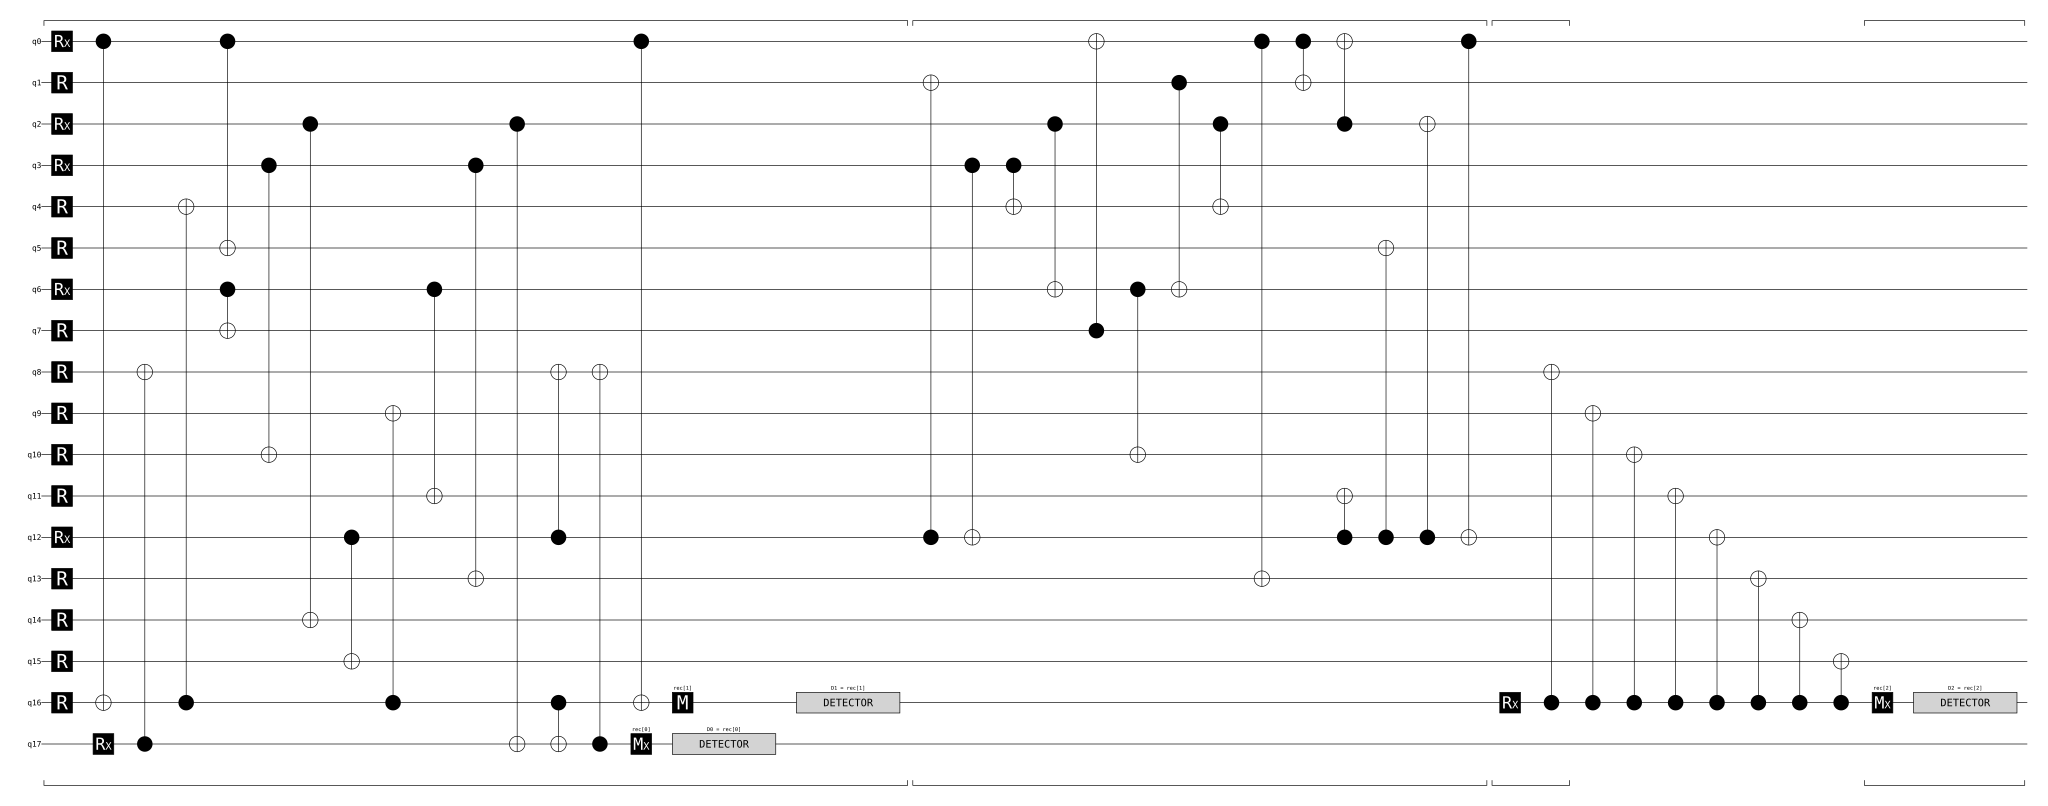

In [22]:
import stim

res_exhaustive = stim.Circuit("""
RX 0
R 1
RX 2 3
R 4 5
RX 6
R 7 8 9 10 11
RX 12
R 13 14 15 16
CX 0 16
RX 17
CX 17 8 16 4 0 5 6 7 3 10 2 14 12 15 16 9 6 11 3 13 2 17 12 8 16 17 17 8
MX 17
CX 0 16
M 16
DETECTOR rec[-2]
DETECTOR rec[-1]
TICK
CX 12 1 3 12 3 4 2 6 7 0 6 10 1 6 2 4 0 13 0 1 2 0 12 11 12 5 12 2 0 12
TICK
RX 16
CX 16 8
TICK
CX 16 9
TICK
CX 16 10
TICK
CX 16 11
TICK
CX 16 12
TICK
CX 16 13
TICK
CX 16 14
TICK
CX 16 15
TICK
MX 16
DETECTOR rec[-1]
# R 31
# TICK
# CX 12 31
# TICK
# R 30
# TICK
# CX 10 30
# TICK
# R 29
# TICK
# CX 8 29
# TICK
# R 28
# TICK
# CX 5 28
# RX 17
# R 16
# CX 17 16
# RX 19
# R 18
# CX 19 18
# RX 21
# R 20
# CX 21 20
# RX 23
# R 22
# CX 23 22
# RX 25
# R 24
# CX 25 24
# RX 27
# R 26
# CX 27 26 14 16 15 18 7 20 3 22 6 24
# TICK
# CX 12 16 6 18 5 20 8 22 1 26
# TICK
# CX 10 16 14 18 12 22 7 24 5 26
# TICK
# CX 8 16 12 20 7 22 2 24 14 26
# TICK
# CX 17 16
# MX 17
# DETECTOR rec[-1]
# M 16
# DETECTOR rec[-1]
# CX 23 22
# MX 23
# DETECTOR rec[-1]
# M 22
# DETECTOR rec[-1]
# CX 7 18 14 20 3 24 10 26
# TICK
# CX 19 18
# MX 19
# DETECTOR rec[-1]
# M 18
# DETECTOR rec[-1]
# CX 21 20
# MX 21
# DETECTOR rec[-1]
# M 20
# DETECTOR rec[-1]
# CX 25 24
# MX 25
# DETECTOR rec[-1]
# M 24
# DETECTOR rec[-1]
# CX 27 26
# MX 27
# DETECTOR rec[-1]
# M 26
# DETECTOR rec[-1]
# CX 5 28
# TICK
# M 28
# DETECTOR rec[-1]
# TICK
# CX 8 29
# TICK
# M 29
# DETECTOR rec[-1]
# TICK
# CX 10 30
# TICK
# M 30
# DETECTOR rec[-1]
# TICK
# CX 12 31
# TICK
# M 31
# DETECTOR rec[-1]
# TICK
# RX 17
# R 16
# CX 17 16 3 16
# TICK
# CX 5 16
# TICK
# CX 10 16
# TICK
# CX 12 16
# TICK
# CX 17 16
# MX 17
# DETECTOR rec[-1]
# M 16
# DETECTOR rec[-1]
""")

res_exhaustive.diagram('timeline-svg')

In [2]:
with open("res_exhaustive.svg", "w") as f:
    f.write(str(res_exhaustive.diagram("timeline-svg")))